In [2]:
import torch
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#print(f"Using device: {device}")


In [15]:
words = open('names.txt', 'r').read().splitlines()
split1 = int(len(words)*0.8)
split2 = int(len(words)*0.9)
words_train = words[:split1]
words_dev = words[split1:split2]
words_test = words[split2:]

chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [34]:
xs_train, xs_dev, xs_test, ys_train, ys_dev, ys_test = [],[],[],[],[],[]
for w in words_train: 
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        xs_train.append(stoi[ch1])
        ys_train.append(stoi[ch2])

for w in words_dev: 
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        xs_dev.append(stoi[ch1])
        ys_dev.append(stoi[ch2])

for w in words_test: 
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        xs_test.append(stoi[ch1])
        ys_test.append(stoi[ch2])

#init
xs_train = torch.tensor(xs_train)
ys_train = torch.tensor(ys_train)
xs_dev = torch.tensor(xs_dev)
ys_dev = torch.tensor(ys_dev)
xs_test = torch.tensor(xs_test)
ys_test = torch.tensor(ys_test)


g = torch.Generator().manual_seed(1)
xenc_train = F.one_hot(xs_train,num_classes=27).float()
xenc_test = F.one_hot(xs_test,num_classes=27).float()
W = torch.randn((27,27), generator=g, requires_grad=True)
num_train = xs_train.nelement()
num_test = xs_test.nelement()

3.8638992309570312
3.6156721115112305
3.4269440174102783
3.279475688934326
3.1669695377349854
3.0815930366516113
3.014373779296875
2.9594404697418213
2.913670301437378
2.875063419342041
2.8421504497528076
2.813835859298706
2.789290189743042
2.767866611480713
2.749041795730591
2.732377290725708
2.7175064086914062
2.7041237354278564
2.6919820308685303
2.6808838844299316
2.6706738471984863
2.6612308025360107
2.652458667755127
2.6442811489105225
2.6366372108459473
2.6294751167297363
2.6227524280548096
2.6164333820343018
2.610485315322876
2.6048812866210938
2.5995960235595703
2.5946059226989746
2.589891195297241
2.585432767868042
2.5812125205993652
2.577214002609253
2.5734219551086426
2.5698230266571045
2.566403388977051
2.5631511211395264
2.5600550174713135
2.5571045875549316
2.5542900562286377
2.551602602005005
2.549034357070923
2.5465776920318604
2.5442259311676025
2.5419723987579346
2.539811134338379
2.5377371311187744
2.5357449054718018
2.533829927444458
2.5319881439208984
2.5302152633

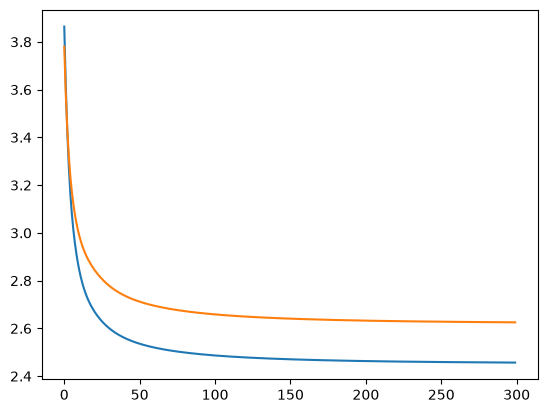

In [35]:
loss_train = []
loss_test = []

for k in range(300):
    #forward train
    logits_train = xenc_train @ W
    counts_train = logits_train.exp()
    probs_train = counts_train / counts_train.sum(1,keepdims=True)
    l = -probs_train[torch.arange(num_train), ys_train].log().mean() + 0.01*(W**2).mean()
    print(l.item())
    loss_train.append(l.item())


    # forward test
    logits_test = xenc_test @ W
    counts_test = logits_test.exp()
    probs_test = counts_test / counts_test.sum(1,keepdims=True)
    l_test = -probs_test[torch.arange(num_test), ys_test].log().mean() + 0.01*(W**2).mean()
    loss_test.append(l_test.item())
    #backward
    W.grad = None
    l.backward()

    #update
    W.data += -25 * W.grad
plt.plot(loss_train)
plt.plot(loss_test)
print(f'train loss - {l}; test loss - {l_test}')


In [94]:
g = torch.Generator().manual_seed(1)
for k in range(10):
    out = []
    ix =  0

    while True:
        xenc = F.one_hot(torch.tensor([ix]),num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(probs, num_samples=1,replacement = True, generator = g).item()
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))

anzorig
lia
ay
h
jxaliss
mele
bemartri
rielciylendumadepionyonera
d
celilonalalieysh


Using device: mps
